# Protocol 4: Estimating Assembly from Tandem Mass Spectrometry

This notebook implements the measurement route described by [Jirasek et al. (2024)](https://doi.org/10.1021/acscentsci.4c00120).

It estimates the molecular assembly (MA) index of a compound directly from its tandem mass spectrometry data, without using its structure. The test compound is a phosphonate ester whose assembly index is independently known to be 14; the structure is used only to render a reference figure and to check the final answer.

## Running it

Run this notebook from its own directory so the figures it saves land beside
it. In JupyterLab:

```bash
cd examples/protocols/4
jupyter lab protocol_4.ipynb
```

Or headlessly, which is how the committed outputs were produced:

```bash
cd examples/protocols/4
jupyter nbconvert --to notebook --execute --inplace protocol_4.ipynb
```

Use **Run All** so the total-time cell at the end measures the whole workflow.

The sample data is bundled as `Sample_#15_Stepped_MS3.tar.xz` and unpacked by the notebook, so no download is needed. Running it writes `Sample_#15_Stepped_MS3.mzML` and a `temp_mzml_output/` directory beside the notebook.

## Timing

The heavy steps below start with the `%%time` cell magic. Read the **Wall
time** it reports. The parallel steps spread work across every CPU core, and
`%%time` counts CPU time for the notebook's own process only, not the worker
pool, so wall time is the figure to compare. The times shown were
recorded on a 28-core machine and will differ on yours.

In [1]:
%matplotlib inline
import contextlib
import io
import os
import re
import tarfile
import time
from pathlib import Path

import matplotlib.pyplot as plt

import assemblytheorytools as att

print(f"CPU cores available: {os.cpu_count()}")
_t_start = time.perf_counter()

CPU cores available: 28


## Parameters

In [2]:
# The known test compound. The structure is used only for the reference figure
# and the final check; the MA estimate never sees it.
SMILES = 'COC(=O)C(NC(=O)OC(C)(C)C)P(=O)(OC)OC'
MW = 297.2               # molecular weight, Da
MA_REFERENCE = 14        # independently known assembly index
TARGET_PARENT_MZ = 296.26  # parent ion we expect in the spectra

# Bundled data and where the mzML parser writes its output.
ARCHIVE = 'Sample_#15_Stepped_MS3.tar.xz'
MZML_FILE = Path('Sample_#15_Stepped_MS3.mzML')
OUTPUT_DIR = Path('temp_mzml_output')

# Peak-processing thresholds (rma_process).
MIN_REL_INTENSITY = 0.01     # drop peaks below 1% of the base peak
MAX_NUM_PEAKS = 20           # keep at most this many peaks per spectrum
MASS_TOL = 0.05              # m/z tolerance for matching parents and children
MIN_ABS_INTENSITY = {1: 10 ** 6, 2: 10 ** 4, 3: 10 ** 3}  # per MS level

MAX_LEVEL = 3            # deepest MS level to include in the tree
PROGRESS_LEVELS = 2      # recursion depth reported by the MA estimator

print(f"Compound: {SMILES}")
print(f"Molecular Weight: {MW}")
print(f"Reference MA: {MA_REFERENCE}")
print(f"Target Parent m/z: {TARGET_PARENT_MZ}")

Compound: COC(=O)C(NC(=O)OC(C)(C)C)P(=O)(OC)OC
Molecular Weight: 297.2
Reference MA: 14
Target Parent m/z: 296.26


### 1. Reference structure

Render the 3D structure of the known compound. This is for orientation only:
everything after this point works from the spectra alone.

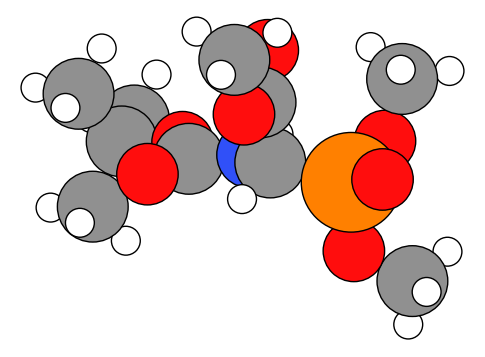

In [3]:
atoms = att.smiles_to_atoms(SMILES)
fig, ax = att.plot_ase_atoms(atoms, 'example_atoms.png', rotation='30x,30y,0z')
plt.show()

*The 3D structure of the test compound, shown for reference only.*

### 2. Data extraction and parsing

Unpack the bundled archive and parse the mzML file into structured DataFrames,
one per MS level. `filter='data'` is the safe extraction filter.

In [4]:
%%time
with tarfile.open(ARCHIVE, "r:xz") as tar:
    tar.extractall(path='.', filter='data')

OUTPUT_DIR.mkdir(exist_ok=True)
att.process_mzml_file(filename=str(MZML_FILE), out_dir=str(OUTPUT_DIR))

json_file = OUTPUT_DIR / f"ripper_{MZML_FILE.stem}.json"

print("Converting JSON to DataFrames...")
raw_data = att.process_mzml_json(json_file)

print(f"MS levels: {list(raw_data.keys())}")
for level, frame in raw_data.items():
    print(f"  MS{level}: {len(frame):,} peaks")

[03-09-2026|16:44:07] - MzMLRipper::INFO -- Parsing file: Sample_#15_Stepped_MS3.mzML...


[03-09-2026|16:44:07] - MzMLRipper::INFO -- Parsing complete!
Total Spectra:            781


[03-09-2026|16:44:07] - MzMLRipper::INFO -- Processing spectra...


[03-09-2026|16:44:07] - MzMLRipper::INFO -- Complete


Converting JSON to DataFrames...


MS levels: [1, 2]
  MS1: 5,402 peaks
  MS2: 61,151 peaks
CPU times: user 444 ms, sys: 6.16 ms, total: 451 ms
Wall time: 459 ms


### 3. Spectral filtering

Reduce each MS level to its informative peaks: a 1% relative-intensity floor, a
per-level absolute floor, and a cap of 20 peaks per spectrum.

In [5]:
processed_data = att.rma_process(
    sample=raw_data,
    max_num_peaks=MAX_NUM_PEAKS,
    min_abs_intensity=MIN_ABS_INTENSITY,
    min_rel_intensity=MIN_REL_INTENSITY,
)

for level, frame in processed_data.items():
    print(f"  MS{level}: {len(frame):,} peaks (filtered from {len(raw_data[level]):,})")

  MS1: 4 peaks (filtered from 5,402)
  MS2: 20 peaks (filtered from 61,151)


### 4. Fragmentation tree

Link parent and child ions within the mass tolerance, build the tree, drop MS1
parents that have no fragments, and select the parent closest to the target m/z.

In [6]:
%%time
rooted_data = att.rma_identify_parents(processed_data, mass_tol=MASS_TOL)
tree = att.rma_build_tree(rooted_data, max_level=MAX_LEVEL)

# Keep only parents that actually have fragments.
tree = {parent: children for parent, children in tree.items() if children}

parent_mz = None
for mz in tree.keys():
    if abs(mz - TARGET_PARENT_MZ) < MASS_TOL:
        parent_mz = mz
        break
if parent_mz is None:
    parent_mz = list(tree.keys())[0]

n_fragments = len(tree[parent_mz]) if parent_mz in tree else 0
print(f"Tree created: {len(tree)} parent(s) with MS2 fragments")
print(f"  Parent m/z: {parent_mz:.4f} ({n_fragments} MS2 fragments)")

Tree created: 1 parent(s) with MS2 fragments
  Parent m/z: 296.2583 (20 MS2 fragments)
CPU times: user 6.13 ms, sys: 995 μs, total: 7.12 ms
Wall time: 10.6 ms


### 5. MS2 spectrum

Plot the processed MS2 spectrum with its fragmentation tree overlaid. The
fragments shown are exactly those that feed the recursive estimate below.

Plotting all 20 processed MS2 fragments


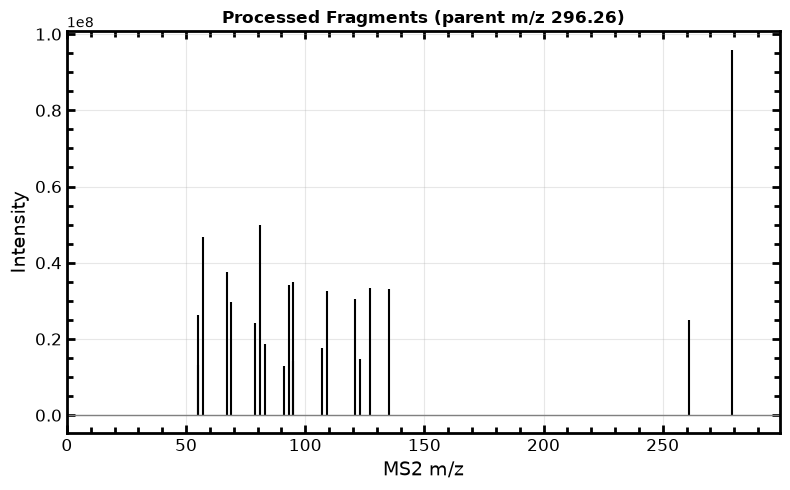

In [7]:
att.plot_ms2_spectrum(processed_data[2], parent_mz, tree)
plt.savefig("processed_MS2.png", dpi=300)
plt.savefig("processed_MS2.svg")
plt.show()

*The processed MS2 spectrum with its fragmentation tree overlaid.*

### 6. MA estimation

Compare two estimates against the known reference value of 14: a first
approximation from molecular weight alone, and the fragment-informed recursive
estimate. The recursive estimator prints diagnostic lines about the shared
sub-fragments it finds; we capture that text with `redirect_stdout` and print
the interesting lines (numbers in brackets are sub-fragments shared by both MS2
fragments), truncating the floats to three decimals.

In [8]:
%%time
est = att.MAEstimator(tol=MASS_TOL)

# First approximation: mass only.
ma_first = float(est.estimate_by_MW(parent_mz, has_children=False).mean())

# Recursive estimate: fragment-informed. Capture its diagnostic output.
buffer = io.StringIO()
with contextlib.redirect_stdout(buffer):
    ma_recursive = float(est.estimate_MA(tree, parent_mz, progress_levels=PROGRESS_LEVELS).mean())

interesting = [
    line for line in buffer.getvalue().split("\n")
    if "Common precursors" in line or "HIT:" in line
]
if interesting:
    print("Numbers in [brackets] are shared sub-fragments from both MS2 fragments.")
    print("Common precursors found:")
    for line in interesting:
        formatted_line = re.sub(r"(\d+\.\d{3})\d+", r"\1", line)
        print(f"  {formatted_line}")

Numbers in [brackets] are shared sub-fragments from both MS2 fragments.
Common precursors found:
  Common precursors of 296.258 = 123.116 + 173.141: [67.054]
  Common precursors of 296.258 = 121.101 + 175.157: [67.054, 55.054, 55.017]
  Common precursors of 296.258 = 135.116 + 161.141: [67.054, 69.069, 79.054, 81.069, 55.054, 55.017]
CPU times: user 54.4 ms, sys: 44 μs, total: 54.4 ms
Wall time: 54.3 ms


Report the comparison and the total runtime.

In [9]:
print(f"Parent m/z: {parent_mz:.4f}")
print(f"First approximation (mass-only):       {ma_first:.2f}")
print(f"Recursive MA (fragment-informed):      {ma_recursive:.2f}")
print(f"Reference MA (known value):            {MA_REFERENCE}")
print(f"Total execution time: {time.perf_counter() - _t_start:.2f} seconds")

Parent m/z: 296.2583
First approximation (mass-only):       18.95
Recursive MA (fragment-informed):      13.09
Reference MA (known value):            14
Total execution time: 0.97 seconds


## Related documentation

* [Spectroscopy and mass spectrometry](https://assemblytheorytools.readthedocs.io/en/latest/guide/mass_spectrometry.html) — the fragmentation-tree route in detail.
* [API: recursive_ma](https://assemblytheorytools.readthedocs.io/en/latest/api/recursive_ma.html) — the MA estimator.
* [API: tools_mzml](https://assemblytheorytools.readthedocs.io/en/latest/api/tools_mzml.html) — mzML parsing.